# Analise 3 - Melhores voltas por década - tempo médio vs. volta mais rápida

## 1. Introdução

A Fórmula 1 sempre esteve na vanguarda da inovação tecnológica no automobilismo. Um dos melhores indicadores da evolução da performance dos carros ao longo do tempo são os tempos de melhor volta em cada corrida. Esta análise explora como esses tempos evoluíram ao longo das décadas, considerando tanto o tempo médio da melhor volta quanto a volta mais rápida registrada em cada período.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Calcular o tempo médio da melhor volta por década;

    - Identificar a volta mais rápida registrada em cada década;

    - Visualizar a evolução da performance dos carros com base nesses tempos.

## 3. Metodologia

Inicialmente, foram utilizadas duas bases de dados principais:

    - lap_times.csv: contém os tempos de volta de cada piloto em cada corrida (colunas: raceId, driverId, lap, milliseconds);

    - races.csv: usado para obter o ano de cada corrida;

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [6]:
import pandas as pd

# Carregamento dos dados
laps = pd.read_csv("lap_times.csv")
races = pd.read_csv("races.csv")

# Adicionar o ano de cada corrida
laps = laps.merge(races[["raceId", "year"]], on="raceId", how="left")

# Criar coluna de década
laps["decade"] = (laps["year"] // 10) * 10

# Melhor volta de cada corrida (menor tempo em milissegundos)
melhor_volta_corrida = laps.groupby("raceId")["milliseconds"].min().reset_index()
melhor_volta_corrida = melhor_volta_corrida.merge(races[["raceId", "year"]], on="raceId")
melhor_volta_corrida["decade"] = (melhor_volta_corrida["year"] // 10) * 10

resumo_decada = (melhor_volta_corrida.groupby("decade")["milliseconds"].agg(["mean", "min"]).reset_index().rename(columns={"mean": "media_melhor_volta", "min": "melhor_volta"}))


## 4. Análise de

#### 4.1 Tempo médio de pit stop por ano

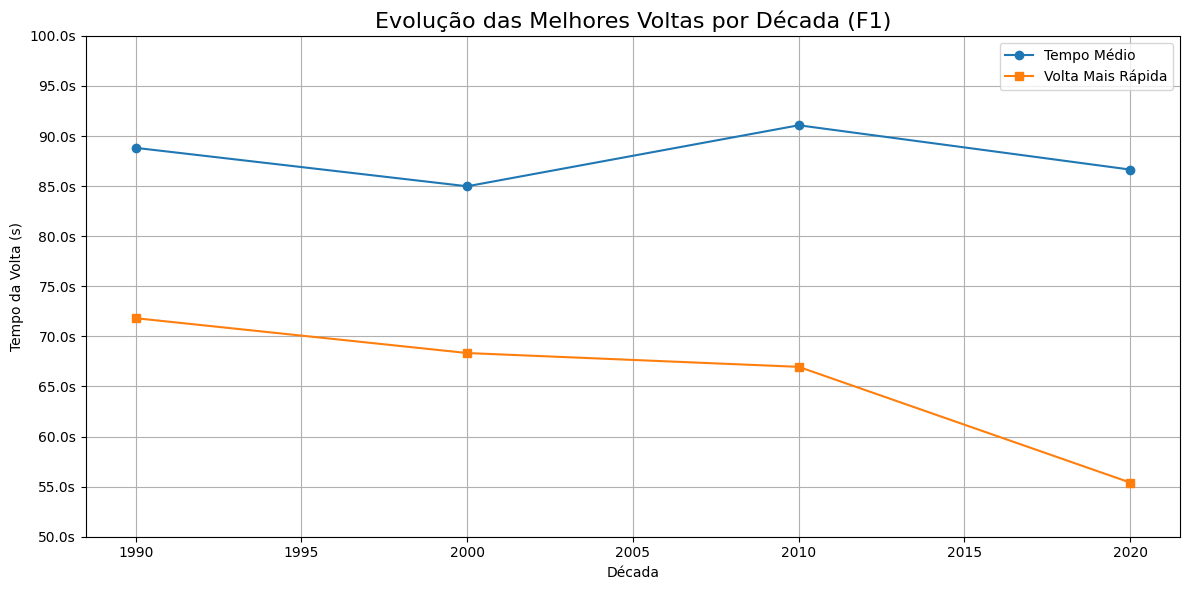

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Linhas
plt.plot(resumo_decada["decade"], resumo_decada["media_melhor_volta"], marker="o", label="Tempo Médio")
plt.plot(resumo_decada["decade"], resumo_decada["melhor_volta"], marker="s", label="Volta Mais Rápida")

# Ajuste para milissegundos → segundos
plt.gca().set_ylim(bottom=resumo_decada[["melhor_volta", "media_melhor_volta"]].min().min() - 1000)

# Eixo formatado em segundos
plt.gca().set_yticks(range(50000, 100001, 5000))  # Ajuste se necessário
plt.gca().set_yticklabels([f"{ms/1000:.1f}s" for ms in range(50000, 100001, 5000)])

plt.title("Evolução das Melhores Voltas por Década (F1)", fontsize=16)
plt.xlabel("Década")
plt.ylabel("Tempo da Volta (s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Conclusão

A análise mostra que:

    - Houve uma redução significativa nos tempos médios de volta ao longo das décadas, evidenciando avanços em aerodinâmica, motores, pneus e estratégias.

    - A volta mais rápida da história ocorreu em décadas mais recentes, o que confirma o aumento de desempenho.

    - Apesar disso, em algumas décadas (como 2010s), os tempos médios estabilizaram ou aumentaram ligeiramente, o que pode estar relacionado a mudanças de regulamento para maior segurança ou economia de combustível.